데이터 카운팅을 시작합니다...

✅ 'txts/news/bitkinds_news_2026*.txt': 총 38개 파일에서 624건 발견
✅ 'txts/apt_real_estate/apt_data_2026*.txt': 총 7개 파일에서 33823건 발견
✅ 'txts/apt_real_estate/apt_rent_data_2026*.txt': 총 7개 파일에서 67788건 발견
✅ 'txts/land_real_estate/land_data_2026*.txt': 총 7개 파일에서 12957건 발견
✅ 'txts/officetel_real_estate/officetel_data_2026*.txt': 총 7개 파일에서 2590건 발견
✅ 'txts/officetel_real_estate/officetel_rent_data_2026*.txt': 총 7개 파일에서 19340건 발견
✅ 'txts/rh_real_estate/rh_data_2026*.txt': 총 7개 파일에서 5803건 발견
✅ 'txts/rh_real_estate/rh_rent_data_2026*.txt': 총 7개 파일에서 13183건 발견
✅ 'txts/sm_real_estate/sm_data_2026*.txt': 총 7개 파일에서 1177건 발견
✅ 'txts/sm_real_estate/sm_rent_data_2026*.txt': 총 7개 파일에서 28776건 발견

카운팅 완료! 그래프를 그립니다.


/var/folders/75/lkrsdp917slbrpn0f3pnj64h0000gn/T/ipykernel_49843/1896237402.py:73: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=12)


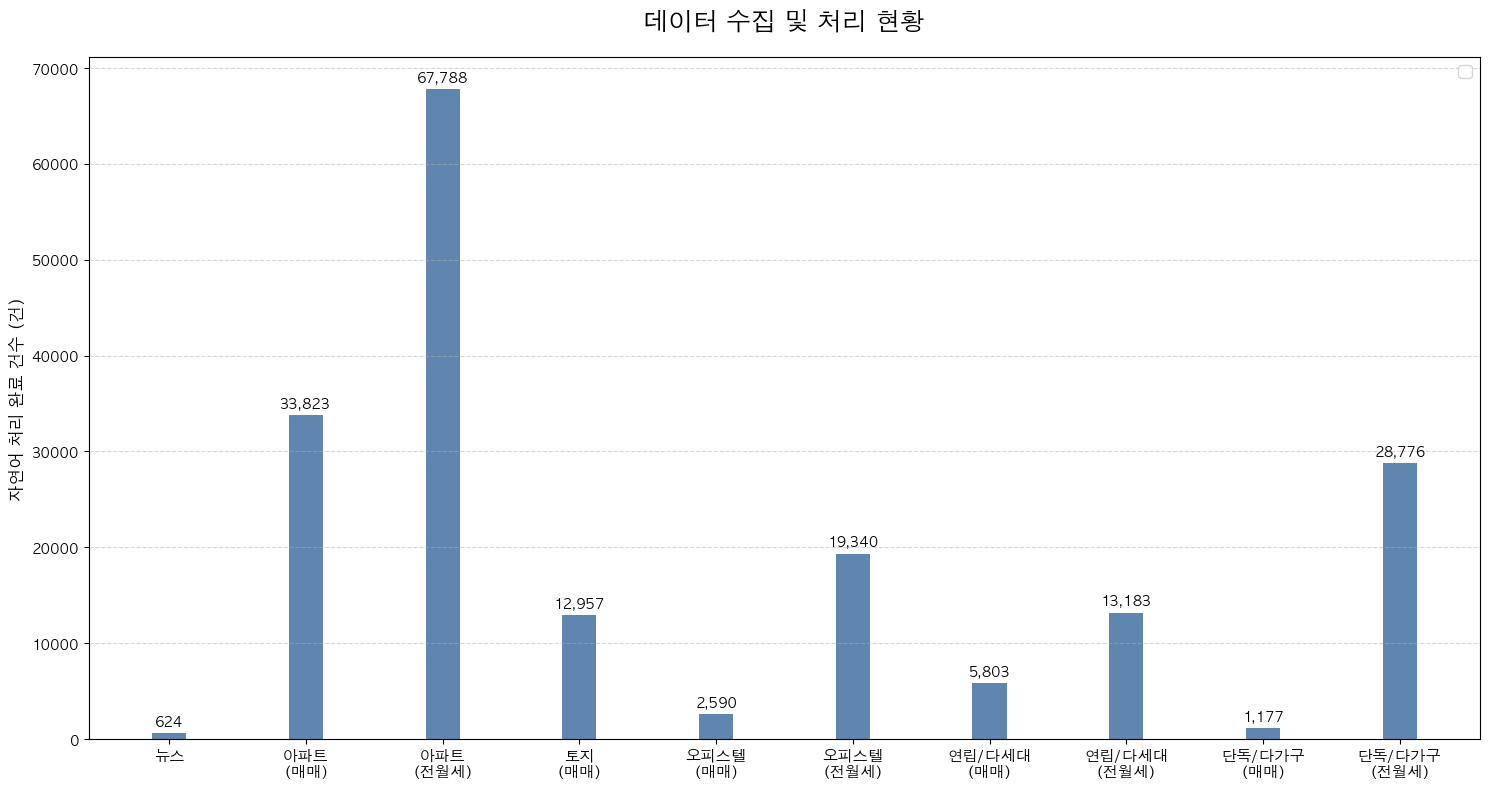

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import glob

# -----------------------------------------------------------
# 1. Mac용 한글 폰트 설정
# -----------------------------------------------------------
plt.rcParams['font.family'] = 'AppleGothic' 
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# -----------------------------------------------------------
# 2. 여러 파일의 줄 수(데이터 건수)를 모두 합산하는 함수
# -----------------------------------------------------------
def count_lines_multiple_files(file_pattern):
    # 패턴(예: apt_data_202601*.txt)과 일치하는 모든 파일 찾기
    matched_files = glob.glob(file_pattern)
    
    if not matched_files:
        print(f"⚠️ 경고: '{file_pattern}' 패턴과 일치하는 파일이 없어 0건으로 처리합니다.")
        return 0
    
    total_lines = 0
    for filepath in matched_files:
        with open(filepath, 'r', encoding='utf-8') as f:
            total_lines += sum(1 for _ in f)
            
    print(f"✅ '{file_pattern}': 총 {len(matched_files)}개 파일에서 {total_lines}건 발견")
    return total_lines

# -----------------------------------------------------------
# 3. 카테고리별 검색 패턴 매핑 (* 기호 활용)
# 형태: '카테고리명': ('1월 파일 패턴', '2월 파일 패턴')
# -----------------------------------------------------------
file_mapping = {
    '뉴스': ('txts/news/bitkinds_news_2026*.txt'),
    '아파트\n(매매)': ('txts/apt_real_estate/apt_data_2026*.txt'),
    '아파트\n(전월세)': ('txts/apt_real_estate/apt_rent_data_2026*.txt'),
    '토지\n(매매)': ('txts/land_real_estate/land_data_2026*.txt'),
    '오피스텔\n(매매)': ('txts/officetel_real_estate/officetel_data_2026*.txt'),
    '오피스텔\n(전월세)': ('txts/officetel_real_estate/officetel_rent_data_2026*.txt'),
    '연립/다세대\n(매매)': ('txts/rh_real_estate/rh_data_2026*.txt'),
    '연립/다세대\n(전월세)': ('txts/rh_real_estate/rh_rent_data_2026*.txt'),
    '단독/다가구\n(매매)': ('txts/sm_real_estate/sm_data_2026*.txt'),
    '단독/다가구\n(전월세)': ('txts/sm_real_estate/sm_rent_data_2026*.txt'),
}

categories = list(file_mapping.keys())
data = []

# 설정한 패턴의 파일들을 모두 찾아 읽고 리스트에 담기
print("데이터 카운팅을 시작합니다...\n")
# 월단위로 나누지 않음 
for category, (pattern) in file_mapping.items():
    count = count_lines_multiple_files(pattern)
    data.append(count)
print("\n카운팅 완료! 그래프를 그립니다.")

# 4. 그래프 그리기 
# -----------------------------------------------------------
x = np.arange(len(categories))  
width = 0.25  

fig, ax = plt.subplots(figsize=(15, 8)) 

rects1 = ax.bar(x, data, width, color='#4e79a7', alpha=0.9) # 부동산 관련 법률 110건 추가해줘

# 5. 레이아웃 및 디자인 꾸미기
# -----------------------------------------------------------
ax.set_ylabel('자연어 처리 완료 건수 (건)', fontsize=12, fontweight='bold')
ax.set_title('데이터 수집 및 처리 현황', fontsize=18, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:,}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)

plt.tight_layout()
plt.show()